In [1]:
from __future__ import annotations
from typing import Dict, List, Optional, Tuple, Iterable
import os, ast, re
import pandas as pd
import numpy as np

# ------------------------ parsing & normalization ------------------------

_listish = (list, tuple, set, np.ndarray)

def _normalize_id(x: str, *, strip_version: bool = True, to_upper: bool = False) -> str:
    """Normalize a gene ID for matching."""
    if x is None:
        return ""
    s = str(x).strip().strip("'\"")
    if strip_version and "." in s:
        # Common for Ensembl IDs: ENSG..., ENSDARG... etc.
        s = s.split(".", 1)[0]
    if to_upper:
        s = s.upper()
    return s

def _parse_intersection_cell(cell) -> List[str]:
    """Parse g:Profiler intersection values robustly into a list of strings."""
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    # Case 1: already list-like
    if isinstance(cell, _listish):
        return [str(x) for x in cell]
    s = str(cell).strip()
    if not s:
        return []
    # Case 2: stringified Python list → use literal_eval safely
    if s.startswith("[") and s.endswith("]"):
        try:
            val = ast.literal_eval(s)
            if isinstance(val, _listish):
                return [str(x) for x in val]
        except Exception:
            pass
    # Case 3: generic delimited string (commas / semicolons / pipes / whitespace)
    s = s.replace(";", ",").replace("|", ",")
    parts = re.split(r"[,\s]+", s)
    return [p for p in (q.strip().strip("'\"") for q in parts) if p]

# ------------------------ mapping helpers ------------------------

def build_id_to_name_map(
    mapping_df: pd.DataFrame,
    id_col: str,
    name_col: str,
    *,
    strip_version: bool = True,
    to_upper: bool = False,
) -> Dict[str, str]:
    """Build dict from normalized ID -> name."""
    if id_col not in mapping_df.columns or name_col not in mapping_df.columns:
        raise ValueError(f"Mapping needs columns '{id_col}' and '{name_col}'. Found: {list(mapping_df.columns)}")
    tmp = mapping_df[[id_col, name_col]].dropna(subset=[id_col]).copy()
    tmp[id_col] = tmp[id_col].astype(str).map(lambda x: _normalize_id(x, strip_version=strip_version, to_upper=to_upper))
    tmp[name_col] = tmp[name_col].astype(str).str.strip()
    # keep first non-null per ID
    tmp = tmp.drop_duplicates(subset=[id_col], keep="first")
    return dict(zip(tmp[id_col], tmp[name_col]))

def translate_intersection_genes_df(
    enriched_df: pd.DataFrame,
    mapping_df: pd.DataFrame,
    map_id_col: str,
    map_name_col: str,
    *,
    gene_col: str = "intersection_genes",
    keep_unmapped: bool = True,
    new_col_suffix: str = "_names",
    strip_version: bool = True,
    to_upper: bool = False,
) -> Tuple[pd.DataFrame, dict, pd.Series]:
    """
    Add '<gene_col>_names' by translating comma/list-formatted IDs -> names.
    Returns (translated_df, stats_dict, unmapped_counts_series).
    """
    if gene_col not in enriched_df.columns:
        raise ValueError(f"'{gene_col}' not in enriched_df. Columns: {list(enriched_df.columns)}")

    id2name = build_id_to_name_map(
        mapping_df, map_id_col, map_name_col,
        strip_version=strip_version, to_upper=to_upper
    )

    total_ids = 0
    mapped_ids = 0
    unmapped = []

    def _convert(cell):
        nonlocal total_ids, mapped_ids
        ids_raw = _parse_intersection_cell(cell)
        ids_norm = [_normalize_id(x, strip_version=strip_version, to_upper=to_upper) for x in ids_raw]
        total_ids += len(ids_norm)
        names = []
        for gid, raw in zip(ids_norm, ids_raw):
            nm = id2name.get(gid)
            if nm:
                mapped_ids += 1
                names.append(nm)
            elif keep_unmapped:
                names.append(raw)  # keep original token for visibility
                unmapped.append(gid or raw)
            else:
                unmapped.append(gid or raw)
        return ",".join(names)

    out = enriched_df.copy()
    out[f"{gene_col}{new_col_suffix}"] = out[gene_col].apply(_convert)

    unmapped_counts = pd.Series(unmapped, dtype="object").value_counts().head(50) if len(unmapped) else pd.Series([], dtype="int64")
    stats = {
        "ids_total": int(total_ids),
        "ids_mapped": int(mapped_ids),
        "pct_mapped": (100.0 * mapped_ids / total_ids) if total_ids else 0.0,
        "unique_ids_in_map": len(id2name),
        "unique_unmapped_sampled": int(unmapped_counts.nunique()) if len(unmapped_counts) else 0,
    }
    return out, stats, unmapped_counts

# ------------------------ file convenience ------------------------

def translate_intersection_genes_file(
    enriched_df: pd.DataFrame,
    mapping_df: pd.DataFrame,
    map_id_col: str,
    map_name_col: str,
    *,
    gene_col: str = "intersection_genes",
    keep_unmapped: bool = True,
    out_path: Optional[str] = None,
    sep: str = "\t",
    strip_version: bool = True,
    to_upper: bool = False,
) -> Tuple[pd.DataFrame, dict, pd.Series, Optional[str]]:
    """
    Jupyter-friendly: take DataFrames directly, translate IDs -> names, and
    optionally write a TSV if out_path is provided.

    Returns: (df_with_names, stats_dict, unmapped_counts_series, written_path_or_None)
    """
    out_df, stats, unmapped_counts = translate_intersection_genes_df(
        enriched_df=enriched_df,
        mapping_df=mapping_df,
        map_id_col=map_id_col,
        map_name_col=map_name_col,
        gene_col=gene_col,
        keep_unmapped=keep_unmapped,
        strip_version=strip_version,
        to_upper=to_upper,
    )

    written = None
    if out_path:
        out_df.to_csv(out_path, index=False, sep=sep)
        written = out_path

    return out_df, stats, unmapped_counts, written

In [2]:
# 1) Load your mapping file (has two columns, e.g., gene_id, gene_name)
mapping = pd.read_csv("/path/to/Geneformer_RQfork/data/RNAquarium/xref/drerio_z12-geneid_to_z11-ENSDARG.csv")

In [3]:
# 2) Load the enrichment results (written by your pipeline)
enriched = pd.read_csv("/path/to/Geneformer_RQfork/embeddings/enrich_results/second_to_last_layer_details_enriched_terms.tsv", sep="\t")

In [4]:
mapping

,gene_id,GeneID,ZFIN,miRBase,Ensembl_gene_id_from_NCBI,Ensembl_gene_id_from_ZFIN,Ensembl_gene_id
0,LOC141383674,141383674,NaN,NaN,NaN,NaN,NaN
1,rpl24,192301,ZDB-GENE-020419-25,NaN,ENSDARG00000099104,ENSDARG00000099104,ENSDARG00000099104
2,cep97,386640,ZDB-GENE-031030-11,NaN,ENSDARG00000102407,ENSDARG00000102407,ENSDARG00000102407
3,nfkbiz,100001781,ZDB-GENE-071024-1,NaN,ENSDARG00000102097,ENSDARG00000102097,ENSDARG00000102097
4,eed,550463,ZDB-GENE-050417-287,NaN,ENSDARG00000099640,ENSDARG00000099640,ENSDARG00000099640
...,...,...,...,...,...,...,...
49658,ND6,140536,ZDB-GENE-011205-13,NaN,NaN,ENSDARG00000063922,ENSDARG00000063922
49659,trnE,140527,ZDB-GENE-011205-37,NaN,NaN,NaN,NaN
49660,CYTB,140512,ZDB-GENE-011205-17,NaN,NaN,ENSDARG00000063924,ENSDARG00000063924
49661,trnT,140518,ZDB-GENE-011205-39,NaN,NaN,NaN,NaN


In [5]:
enriched

,set,resolution,cluster,library,go_id,term,intersection_size,intersection_genes,pvalue,pvalue_adj,term_size,query_size
0,RQ,0.2,0,GO:BP,GO:0080090,regulation of primary metabolic process,1516,"['ENSDARG00000099640', 'ENSDARG00000016304', '...",NaN,7.564726e-53,2239,7405
1,RQ,0.2,0,GO:BP,GO:0019219,regulation of nucleobase-containing compound m...,1304,"['ENSDARG00000099640', 'ENSDARG00000016304', '...",NaN,3.063796e-42,1937,7405
2,RQ,0.2,0,GO:BP,GO:0006351,DNA-templated transcription,1243,"['ENSDARG00000099640', 'ENSDARG00000016304', '...",NaN,3.564792e-42,1835,7405
3,RQ,0.2,0,GO:BP,GO:0051252,regulation of RNA metabolic process,1253,"['ENSDARG00000099640', 'ENSDARG00000016304', '...",NaN,1.292621e-40,1861,7405
4,RQ,0.2,0,GO:BP,GO:0006996,organelle organization,1084,"['ENSDARG00000041589', 'ENSDARG00000011299', '...",NaN,3.220399e-39,1584,7405
...,...,...,...,...,...,...,...,...,...,...,...,...
522753,zebrahub-pretrained,40.0,99,GO:MF,GO:0031419,cobalamin binding,2,"['ENSDARG00000091996', 'ENSDARG00000068088']",NaN,1.095589e-03,3,25
522754,zebrahub-pretrained,40.0,99,GO:MF,GO:0019842,vitamin binding,3,"['ENSDARG00000091996', 'ENSDARG00000068088', '...",NaN,2.225510e-02,81,25
522755,zebrahub-pretrained,40.0,99,GO:MF,GO:0004760,L-serine-pyruvate transaminase activity,1,['ENSDARG00000018478'],NaN,4.500846e-02,1,25
522756,zebrahub-pretrained,40.0,99,GO:MF,GO:0008453,alanine-glyoxylate transaminase activity,1,['ENSDARG00000018478'],NaN,4.500846e-02,1,25


In [6]:
# 3) Translate in-memory (keeps original column and adds 'intersection_genes_names')
named_df, stats, unmapped_top, written = translate_intersection_genes_file(
    enriched_df=enriched,
    mapping_df=mapping,
    map_id_col="Ensembl_gene_id",
    map_name_col="gene_id",
    gene_col="intersection_genes",
    keep_unmapped=True,
    out_path="enrich_results/enrichment_enriched_terms.with_names.tsv",  # or None to skip writing
    sep="\t",
    strip_version=True,
)

In [42]:
named_df

,set,resolution,cluster,library,go_id,term,intersection_size,intersection_genes,pvalue,pvalue_adj,term_size,query_size,intersection_genes_names
0,RQ,0.2,0,GO:BP,GO:0080090,regulation of primary metabolic process,1516,"['ENSDARG00000099640', 'ENSDARG00000016304', '...",NaN,7.564726e-53,2239,7405,"eed,tfdp1b,trmt10c,runx1,mbnl2,mnx2b,en1b,alkb..."
1,RQ,0.2,0,GO:BP,GO:0019219,regulation of nucleobase-containing compound m...,1304,"['ENSDARG00000099640', 'ENSDARG00000016304', '...",NaN,3.063796e-42,1937,7405,"eed,tfdp1b,runx1,mnx2b,en1b,alkbh5,dachb,elf2b..."
2,RQ,0.2,0,GO:BP,GO:0006351,DNA-templated transcription,1243,"['ENSDARG00000099640', 'ENSDARG00000016304', '...",NaN,3.564792e-42,1835,7405,"eed,tfdp1b,runx1,mnx2b,gtf3c3,en1b,dachb,elf2b..."
3,RQ,0.2,0,GO:BP,GO:0051252,regulation of RNA metabolic process,1253,"['ENSDARG00000099640', 'ENSDARG00000016304', '...",NaN,1.292621e-40,1861,7405,"eed,tfdp1b,runx1,mnx2b,en1b,alkbh5,dachb,elf2b..."
4,RQ,0.2,0,GO:BP,GO:0006996,organelle organization,1084,"['ENSDARG00000041589', 'ENSDARG00000011299', '...",NaN,3.220399e-39,1584,7405,"adprhl1,blzf1,tuba8l2,pard3ba,alkbh5,actb1,plk..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
387523,zebrahub-pretrained,40.0,99,GO:MF,GO:0031419,cobalamin binding,2,"['ENSDARG00000091996', 'ENSDARG00000068088']",NaN,1.095589e-03,3,25,"tcnbb,tcnba"
387524,zebrahub-pretrained,40.0,99,GO:MF,GO:0019842,vitamin binding,3,"['ENSDARG00000091996', 'ENSDARG00000068088', '...",NaN,2.225510e-02,81,25,"tcnbb,tcnba,rhol"
387525,zebrahub-pretrained,40.0,99,GO:MF,GO:0004760,L-serine-pyruvate transaminase activity,1,['ENSDARG00000018478'],NaN,4.500846e-02,1,25,agxtb
387526,zebrahub-pretrained,40.0,99,GO:MF,GO:0008453,alanine-glyoxylate transaminase activity,1,['ENSDARG00000018478'],NaN,4.500846e-02,1,25,agxtb


In [7]:
named_df["perc_clu_in_GO"] = named_df["intersection_size"]/named_df["query_size"]
named_df["perc_GO_in_clu"] = named_df["intersection_size"]/named_df["term_size"]

In [8]:
# RQ slice
mask = (
(named_df["set"] == "RQ")
)
slice_df = named_df.copy().loc[mask]

slice_df = slice_df.drop(["intersection_genes"], axis=1)

# sort
slice_df = slice_df.sort_values(by="perc_clu_in_GO", ascending=False, na_position="last")

# write to file
slice_df.to_csv("enrich_results/named_enrich_df_RQ_slice.csv")

In [19]:
# RQ slice not in co-expression
coexpr_GO = named_df.loc[named_df["set"] == "co-expression", "go_id"].to_list()
mask = (named_df["set"] == "RQ") & ~named_df["go_id"].isin(coexpr_GO)


slice_df = named_df.copy().loc[mask]

slice_df = slice_df.drop(["intersection_genes"], axis=1)

# sort
slice_df = slice_df.sort_values(by="perc_clu_in_GO", ascending=False, na_position="last")

# write to file
slice_df.to_csv("enrich_results/named_enrich_df_RQ_slice_not-in_coexpr.csv")

In [22]:
# immune slice of RQ and coexpression 
mask = (
    named_df["term"].str.contains("immun", case=False, na=False)
    & named_df["set"].isin(["RQ", "co-expression"])
)

slice_df = named_df.copy().loc[mask]

# compute percent cluster in GO
slice_df["perc_clu_in_GO"] = slice_df["intersection_size"]/slice_df["query_size"]
slice_df["perc_GO_in_clu"] = slice_df["intersection_size"]/slice_df["term_size"]

slice_df = slice_df.drop(["intersection_genes"], axis=1)

# sort
slice_df = slice_df.sort_values(by="perc_clu_in_GO", ascending=False, na_position="last")

# write to file
slice_df.to_csv("enrich_results/named_enrich_df_immune_slice.csv")

In [ ]:
# analysis

In [66]:
resolution = 0.8

mask = (named_df["resolution"] == resolution) 

slice_df = named_df.copy().loc[mask]

coexpr_GO = slice_df.loc[slice_df["set"] == "co-expression", "go_id"].to_list()
RQ_GO = slice_df.loc[slice_df["set"] == "RQ", "go_id"].to_list()
mask2 = (slice_df["set"] == "RQ") & ~slice_df["go_id"].isin(coexpr_GO)

slice_df2 = slice_df.copy().loc[mask2]

slice_df2 = slice_df2.drop(["intersection_genes"], axis=1)

# write to file
slice_df2.to_csv(f"enrich_results/named_enrich_df_immune_slice_res{resolution}.csv")

# count overlap
union = list(set(coexpr_GO) | set(RQ_GO))        # [1, 2, 3, 4] (order arbitrary)
intersect = list(set(coexpr_GO) & set(RQ_GO))    # [2, 3]       (order arbitrary)
RQ_only = list(set(RQ_GO) - set(coexpr_GO))   # items in a but not in b
coexpr_only = list(set(coexpr_GO) - set(RQ_GO))   # items in b but not in a
print(f"union: {len(union)}")
print(f"intersect: {len(intersect)}")
print(f"RQ only: {len(RQ_only)}")
print(f"coexpr_only: {len(coexpr_only)}")

union: 5058
intersect: 3042
RQ only: 1157
coexpr_only: 859


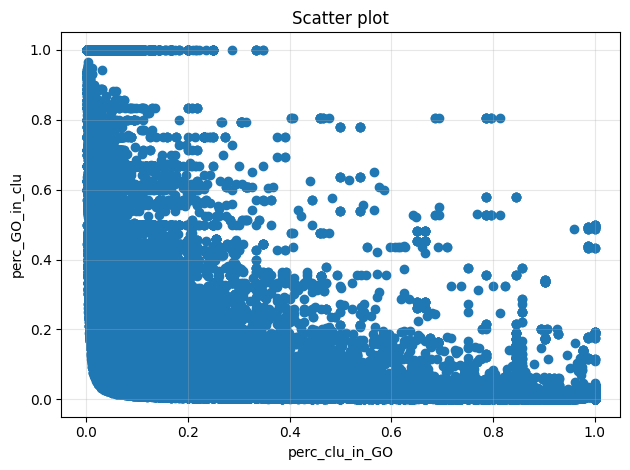

In [46]:
# From a pandas DataFrame
import pandas as pd
import matplotlib.pyplot as plt

# example data


plt.figure()
plt.scatter(slice_df["perc_clu_in_GO"], slice_df["perc_GO_in_clu"] )
plt.xlabel("perc_clu_in_GO")
plt.ylabel("perc_GO_in_clu")
plt.title("Scatter plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


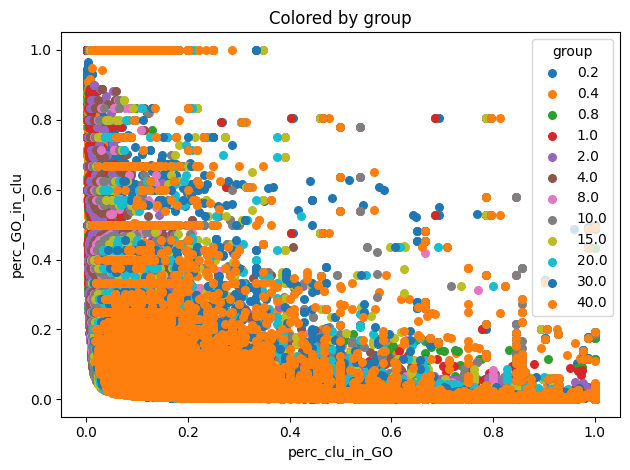

In [47]:
import matplotlib.pyplot as plt

# assume df has: x, y, group (group is categorical/strings)
plt.figure()
for name, g in slice_df.groupby("resolution"):
    plt.scatter(g["perc_clu_in_GO"], g["perc_GO_in_clu"], label=name, s=30)
plt.xlabel("perc_clu_in_GO"); plt.ylabel("perc_GO_in_clu"); plt.title("Colored by group")
plt.legend(title="group")
plt.tight_layout()
plt.show()


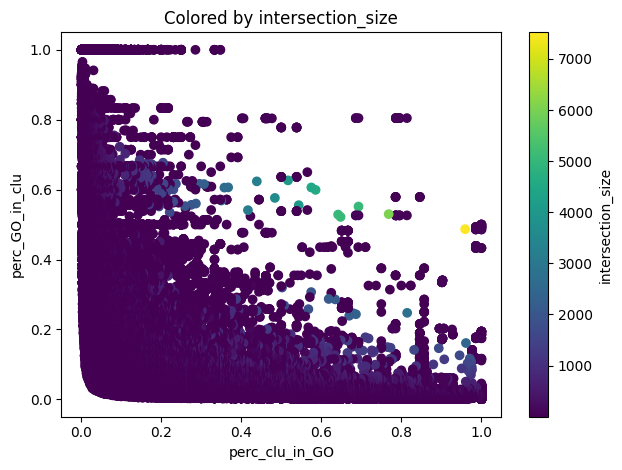

In [48]:
import matplotlib.pyplot as plt

# assume df has columns: x, y, z  (z is numeric)
fig = plt.figure()
sc = plt.scatter(slice_df["perc_clu_in_GO"], slice_df["perc_GO_in_clu"], c=slice_df["intersection_size"], cmap="viridis")
plt.xlabel("perc_clu_in_GO"); plt.ylabel("perc_GO_in_clu"); plt.title("Colored by intersection_size")
plt.colorbar(sc, label="intersection_size")
plt.tight_layout()
plt.show()

In [56]:
# short list

mask = np.logical_and.reduce([
    named_df["perc_clu_in_GO"] > 0.4,
    named_df["set"].eq("RQ"),
    named_df["perc_GO_in_clu"] > 0.4,
])
slice_df = named_df.copy().loc[mask]

slice_df = slice_df.drop(["intersection_genes"], axis=1)
slice_df.to_csv("enrich_results/high_perc_clusters.csv")

In [57]:
# short list

mask = np.logical_and.reduce([
    named_df["perc_clu_in_GO"] > 0.5,
    named_df["set"].eq("RQ"),
    named_df["perc_GO_in_clu"] > 0.05,
])
slice_df = named_df.copy().loc[mask]

slice_df = slice_df.drop(["intersection_genes"], axis=1)
slice_df.to_csv("enrich_results/high_perc_clu_in_GO.csv")

In [58]:
# short list

mask = np.logical_and.reduce([
    named_df["perc_clu_in_GO"] > 0.05,
    named_df["perc_GO_in_clu"] > 0.5,
    named_df["set"].eq("RQ"),
])
slice_df = named_df.copy().loc[mask]

slice_df = slice_df.drop(["intersection_genes"], axis=1)
slice_df.to_csv("enrich_results/high_perc_GO_in_clu.csv")

In [29]:
# analyze GO terms for clusters with isg15
mask = (
    named_df["intersection_genes_names"].str.contains("isg15", case=False, na=False)
    & (named_df["set"] == "RQ")
)

slice_df = named_df.copy().loc[mask]
slice_df["term"].value_counts()

term
proteolysis                                                     9
catabolic process                                               9
proteolysis involved in protein catabolic process               8
modification-dependent macromolecule catabolic process          8
modification-dependent protein catabolic process                8
protein catabolic process                                       8
protein metabolic process                                       8
macromolecule catabolic process                                 8
binding                                                         7
protein modification process                                    7
protein ubiquitination                                          7
protein modification by small protein conjugation or removal    6
post-translational protein modification                         6
macromolecule modification                                      6
protein modification by small protein conjugation               6
prote

In [19]:
# analyze GO terms for clusters with isg15
mask = (
    named_df["intersection_genes_names"].str.contains("mxa", case=False, na=False)
    & (named_df["set"] == "RQ")
)

slice_df = named_df.copy().loc[mask]
slice_df["term"].value_counts()

term
hydrolase activity                                                                    12
cytoplasm                                                                             11
small molecule binding                                                                10
catalytic activity                                                                    10
ion binding                                                                           10
binding                                                                                7
guanyl ribonucleotide binding                                                          4
guanyl nucleotide binding                                                              4
GTP binding                                                                            4
cellular anatomical structure                                                          3
GTPase activity                                                                        1
nucleotide bindi